In [1]:
# Notebook: Label Insights
#
# Provides a Piki performance report for record labels:
#   - How a label's roster stacks up overall (avg score, ratings volume)
#   - Which artists in a label are resonating most with Piki users
#   - Best songs per label ranked by Piki score and liked/superlike rates
#   - Full label report in one call

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

%run db.py

In [2]:
def get_labels(min_ratings=50):
    """
    Return all labels with aggregate performance metrics.

    Columns: label, artists, songs, avg_piki_score,
             liked_rate, superliked_rate, total_ratings
    Only includes songs with at least min_ratings total votes.
    """
    sql = '''
        SELECT
            a.label,
            COUNT(DISTINCT c.artist_id)                                   AS artists,
            COUNT(DISTINCT ps.song_id)                                    AS songs,
            ROUND(AVG(ps.piki_score), 1)                                  AS avg_piki_score,
            SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes)       AS total_ratings,
            ROUND(
                SUM(ps.num_likes + ps.num_superlikes) /
                NULLIF(SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes), 0)
            , 3)                                                          AS liked_rate,
            ROUND(
                SUM(ps.num_superlikes) /
                NULLIF(SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes), 0)
            , 3)                                                          AS superliked_rate
        FROM piki_score ps
        INNER JOIN catalog c  ON ps.song_id   = c.id
        INNER JOIN artists a  ON c.artist_id  = a.id
        WHERE a.label IS NOT NULL
          AND a.label != ''
          AND (ps.num_likes + ps.num_superlikes + ps.num_dislikes) >= %s
        GROUP BY a.label
        HAVING total_ratings >= 200
        ORDER BY avg_piki_score DESC
    ''' % min_ratings
    df = pd.DataFrame(DB.fetch(sql))
    for col in ['avg_piki_score', 'liked_rate', 'superliked_rate']:
        df[col] = df[col].astype(float)
    df['total_ratings'] = df['total_ratings'].astype(int)
    return df

In [3]:
labels = get_labels(min_ratings=50)
print(f"{len(labels)} labels with sufficient data")
labels.head(30)

1303 labels with sufficient data


,label,artists,songs,avg_piki_score,total_ratings,liked_rate,superliked_rate
0,Madlib Invazion,1,1,100.0,280,0.604,0.268
1,SÝN RECORDS,1,1,100.0,224,0.688,0.188
2,WMG (Warner Music Norway),1,1,100.0,230,0.561,0.283
3,緑,1,1,100.0,489,0.616,0.186
4,"AMB, Fast Draw",1,1,99.0,291,0.680,0.192
5,Hip Dozer,1,2,99.0,341,0.601,0.235
6,Modern Recordings,1,1,99.0,402,0.590,0.201
7,"StreamWorld Entertainment Classics, Editions A...",1,1,98.0,383,0.546,0.201
8,30th Century Records,1,2,96.5,456,0.537,0.182
9,Elemental Music Records SL,1,1,96.0,303,0.630,0.191


In [4]:
def get_label_artists(label, min_ratings=20):
    """
    Return artists on a label ranked by their best song's Piki score.

    Columns: artist, best_song, piki_score, liked_rate, superliked_rate,
             total_ratings, songs_rated
    """
    sql = '''
        SELECT
            a.name                                                            AS artist,
            MAX(c.title)                                                      AS best_song,
            MAX(ps.piki_score)                                                AS piki_score,
            ROUND(
                SUM(ps.num_likes + ps.num_superlikes) /
                NULLIF(SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes), 0)
            , 3)                                                              AS liked_rate,
            ROUND(
                SUM(ps.num_superlikes) /
                NULLIF(SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes), 0)
            , 3)                                                              AS superliked_rate,
            SUM(ps.num_likes + ps.num_superlikes + ps.num_dislikes)          AS total_ratings,
            COUNT(DISTINCT ps.song_id)                                        AS songs_rated
        FROM piki_score ps
        INNER JOIN catalog c ON ps.song_id  = c.id
        INNER JOIN artists a ON c.artist_id = a.id
        WHERE a.label = '%s'
          AND (ps.num_likes + ps.num_superlikes + ps.num_dislikes) >= %s
        GROUP BY a.id, a.name
        ORDER BY piki_score DESC
    ''' % (label.replace("'", "\\'"), min_ratings)
    df = pd.DataFrame(DB.fetch(sql))
    if df.empty:
        return df
    for col in ['piki_score', 'liked_rate', 'superliked_rate']:
        df[col] = df[col].astype(float)
    df['total_ratings'] = df['total_ratings'].astype(int)
    return df

In [5]:
def get_label_songs(label, min_ratings=20, limit=20):
    """
    Return top songs for a label, ranked by Piki score.

    Columns: artist, title, piki_score, liked_rate, superliked_rate,
             num_likes, num_superlikes, num_dislikes, total_ratings
    """
    sql = '''
        SELECT
            a.name                                                          AS artist,
            c.title,
            ps.piki_score,
            ROUND(
                (ps.num_likes + ps.num_superlikes) /
                NULLIF(ps.num_likes + ps.num_superlikes + ps.num_dislikes, 0)
            , 3)                                                            AS liked_rate,
            ROUND(
                ps.num_superlikes /
                NULLIF(ps.num_likes + ps.num_superlikes + ps.num_dislikes, 0)
            , 3)                                                            AS superliked_rate,
            ps.num_likes,
            ps.num_superlikes,
            ps.num_dislikes,
            (ps.num_likes + ps.num_superlikes + ps.num_dislikes)           AS total_ratings
        FROM piki_score ps
        INNER JOIN catalog c ON ps.song_id  = c.id
        INNER JOIN artists a ON c.artist_id = a.id
        WHERE a.label = '%s'
          AND (ps.num_likes + ps.num_superlikes + ps.num_dislikes) >= %s
        ORDER BY ps.piki_score DESC
        LIMIT %s
    ''' % (label.replace("'", "\\'"), min_ratings, limit)
    df = pd.DataFrame(DB.fetch(sql))
    if df.empty:
        return df
    for col in ['piki_score', 'liked_rate', 'superliked_rate']:
        df[col] = df[col].astype(float)
    return df

In [6]:
def label_report(label, min_ratings=20):
    """
    Print a full Piki performance report for a label:
      - Overall stats
      - Top artists by Piki score
      - Top songs by Piki score
      - Bar charts: liked and superlike rates per artist
    """
    artists = get_label_artists(label, min_ratings=min_ratings)
    songs   = get_label_songs(label,   min_ratings=min_ratings, limit=20)

    if artists.empty:
        print(f"No data found for label: {label}")
        return

    # --- summary header ---
    total_ratings = artists['total_ratings'].sum()
    avg_score     = songs['piki_score'].mean() if not songs.empty else float('nan')
    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Artists with data : {len(artists)}")
    print(f"  Total ratings     : {total_ratings:,}")
    print(f"  Avg Piki score    : {avg_score:.1f}")
    print(f"{'='*55}\n")

    # --- top artists table ---
    print("Top Artists")
    display(artists[['artist', 'best_song', 'piki_score',
                      'liked_rate', 'superliked_rate', 'total_ratings']].head(15))

    # --- top songs table ---
    print("\nTop Songs")
    display(songs[['artist', 'title', 'piki_score',
                   'liked_rate', 'superliked_rate', 'total_ratings']].head(15))

    # --- artist bar chart ---
    plot_df = artists.head(15).sort_values('superliked_rate')
    fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(plot_df) * 0.45)))

    for ax, col, color, label_txt in [
        (axes[0], 'liked_rate',      '#4C9BE8', 'Liked Rate'),
        (axes[1], 'superliked_rate', '#E87C4C', 'Superlike Rate'),
    ]:
        ax.barh(plot_df['artist'], plot_df[col], color=color, alpha=0.8)
        ax.set_xlabel(label_txt)
        ax.set_title(label_txt)
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.grid(axis='x', alpha=0.3)

    fig.suptitle(f"{label} — Artist Performance", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

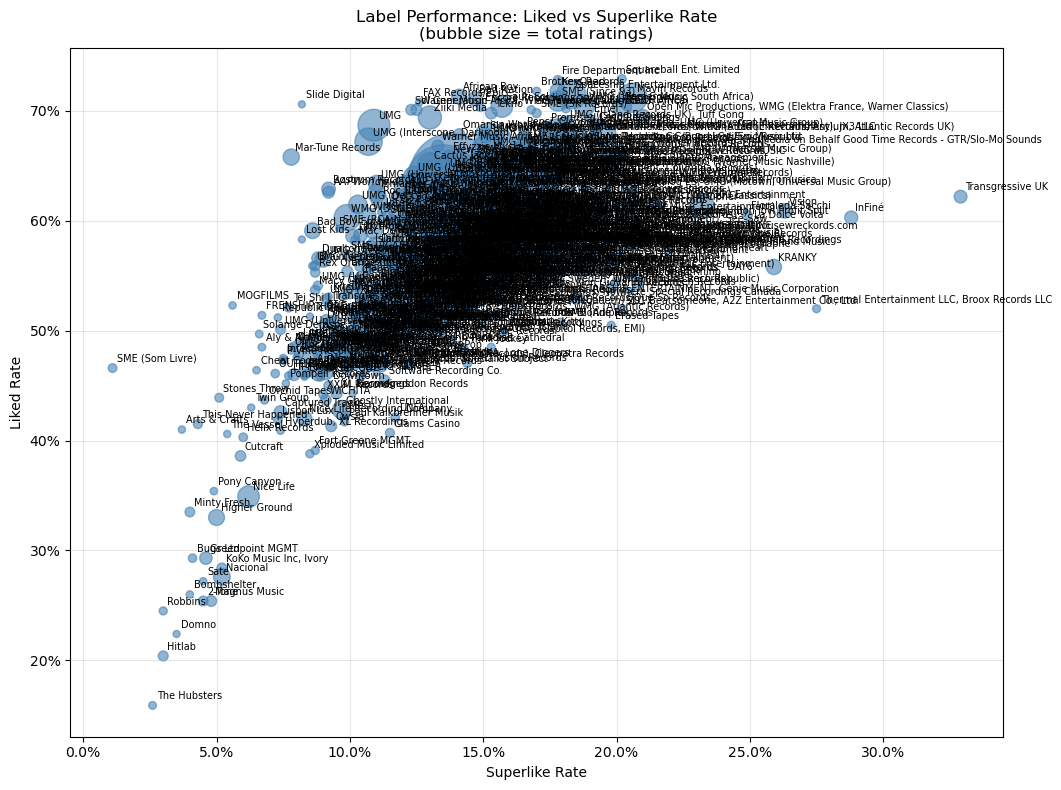

In [7]:
# Scatter: all labels — superlike rate vs liked rate
# Only show labels with enough volume to be meaningful
plot_labels = labels[labels['total_ratings'] >= 500].copy()

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(plot_labels['superliked_rate'], plot_labels['liked_rate'],
           s=plot_labels['total_ratings'] / 20, alpha=0.6, color='steelblue')

for _, row in plot_labels.iterrows():
    ax.annotate(row['label'], (row['superliked_rate'], row['liked_rate']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Superlike Rate')
ax.set_ylabel('Liked Rate')
ax.set_title('Label Performance: Liked vs Superlike Rate\n(bubble size = total ratings)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  Domino
  Artists with data : 16
  Total ratings     : 14,817
  Avg Piki score    : 88.5

Top Artists


,artist,best_song,piki_score,liked_rate,superliked_rate,total_ratings
0,Arctic Monkeys,You Probably Couldn't See for the Lights but Y...,96.0,0.633,0.135,6181
1,Jon Hopkins,We Disappear,89.0,0.497,0.133,1716
2,Cat Power,You Get,87.0,0.469,0.112,1560
3,Hot Chip,To the Moon and Back (Mixed),86.0,0.524,0.131,2163
4,Wet Leg,Wet Dream,83.0,0.612,0.056,178
5,Dirty Projectors,Zombie Conqueror,67.0,0.517,0.101,466
6,Sorry,Starstruck,66.0,0.554,0.066,332
7,Villagers,Summer's Song,65.0,0.519,0.135,104
8,Julia Holter,Marienbad (Live),56.0,0.599,0.039,436
9,Night Moves,Recollections,52.0,0.376,0.049,487



Top Songs


,artist,title,piki_score,liked_rate,superliked_rate,total_ratings
0,Arctic Monkeys,I Want It All,96.0,0.711,0.222,45
1,Arctic Monkeys,Despair In The Departure Lounge,94.0,0.762,0.214,42
2,Arctic Monkeys,Piledriver Waltz,94.0,0.603,0.294,68
3,Arctic Monkeys,From the Ritz to the Rubble,94.0,0.429,0.245,49
4,Arctic Monkeys,Golden Trunks,94.0,0.724,0.172,29
5,Arctic Monkeys,You Probably Couldn't See for the Lights but Y...,90.0,0.615,0.254,169
6,Jon Hopkins,A Drifting Up,89.0,0.557,0.130,115
7,Arctic Monkeys,Fright Lined Dining Room,89.0,0.500,0.194,36
8,Arctic Monkeys,I Bet U Look Good On A Dance Floor,88.0,0.636,0.227,22
9,Arctic Monkeys,Body Paint,88.0,0.800,0.400,20


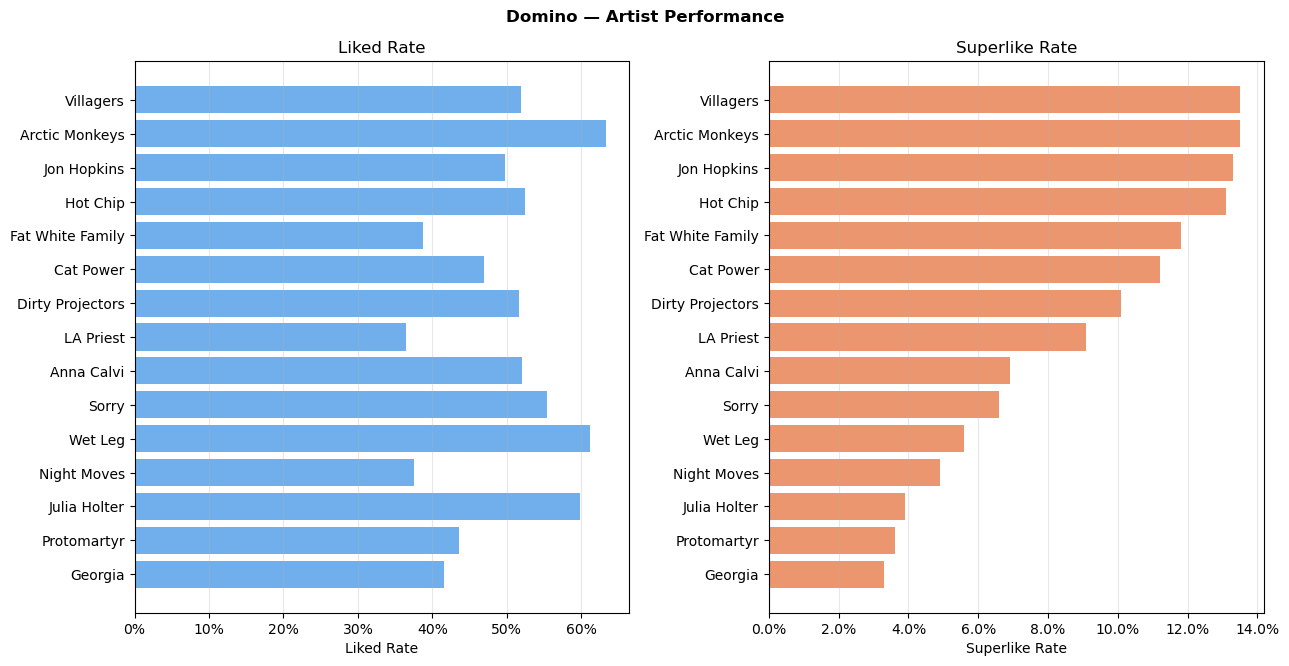

In [8]:
# Example: run a full report for a specific label
# Replace with any label name from the labels table above
label_report('Domino')

  Mexican Summer
  Artists with data : 73
  Total ratings     : 74,234
  Avg Piki score    : 98.4

Top Artists


,artist,best_song,piki_score,liked_rate,superliked_rate,total_ratings
0,Contour,Theresa,100.0,0.618,0.228,545
1,Cate le Bon,Wheel,100.0,0.499,0.147,3378
2,Destroyer,Your Blood,99.0,0.555,0.152,2494
3,Deep Purple,Woman From Tokyo,98.0,0.585,0.110,609
4,Sessa,Vento a Favor,98.0,0.572,0.143,1092
5,F. J. McMahon,The Spirit of the Golden Juice,98.0,0.601,0.230,3298
6,Cigarettes After Sex,Young & Dumb,98.0,0.572,0.132,1611
7,Allah-Las,Yemeni Jade,98.0,0.502,0.125,4703
8,Creedence Clearwater Revival,Up Around The Bend,98.0,0.619,0.210,2278
9,Rihanna,You Da One,98.0,0.679,0.159,12046



Top Songs


,artist,title,piki_score,liked_rate,superliked_rate,total_ratings
0,Cate le Bon,Cyrk,100.0,0.607,0.300,323
1,Contour,Shooting Star,100.0,0.657,0.263,472
2,Cate le Bon,Through The Mill,99.0,0.701,0.517,87
3,Cate le Bon,Out To Sea,99.0,0.563,0.221,231
4,Destroyer,Beggars Might Ride,99.0,0.708,0.206,465
5,Cate le Bon,Falcon Eyed,99.0,0.625,0.510,96
6,Cigarettes After Sex,Neon Moon,98.0,0.585,0.252,123
7,Cigarettes After Sex,Touch,98.0,0.678,0.271,59
8,Cigarettes After Sex,Kiss It Off Me,98.0,0.692,0.308,26
9,Cigarettes After Sex,Pure,98.0,0.563,0.161,112


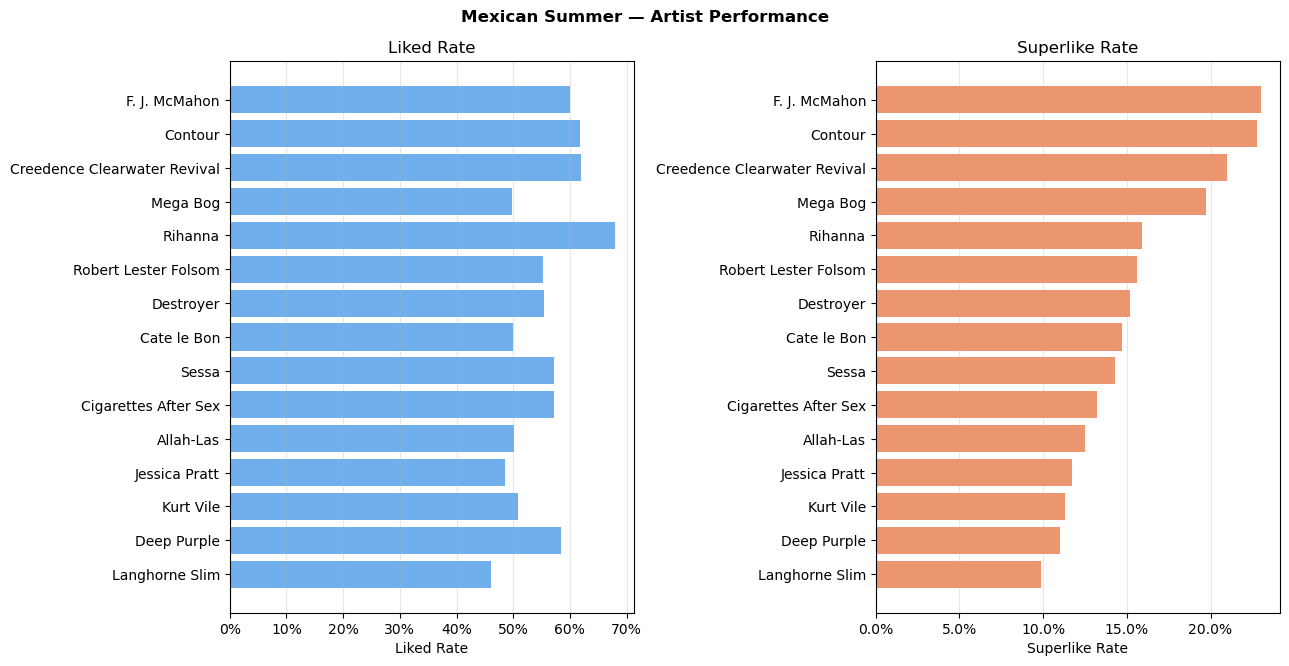

In [9]:
# Example: run a full report for a specific label
# Replace with any label name from the labels table above
label_report('Mexican Summer')

In [13]:
label_report('RVNG')

No data found for label: RVNG
